# Market Data Collection and Initial Exploration

This notebook downloads historical market data for a diversified set of ETFs that will be used throughout the project.

These assets are chosen to represent major asset classes relevant for portfolio construction:

- **SPY** — U.S. equities
- **EFA** — international equities
- **TLT** — long-term U.S. Treasury bonds
- **GLD** — gold
- **VNQ** — real estate

This notebook focuses on:

1. downloading historical adjusted price data  
2. inspecting the dataset  
3. visualizing asset price behavior  

These data will later be used to compute returns, estimate covariance matrices, and build regime-dependent portfolio strategies.

## Motivation

Portfolio optimization depends on the behavior of multiple assets rather than a single stock or fund. To study diversification, we want a set of assets with different risk and return characteristics.

The selected ETFs provide exposure to several major asset classes:

- equities, which tend to offer higher expected return with higher risk
- bonds, which may provide stability during equity downturns
- gold, which can behave differently from stocks and bonds
- real estate, which adds another source of diversification

By analyzing these assets together, we can later estimate expected returns, covariance structure, and ultimately construct optimized portfolios.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

pd.options.display.float_format = "{:.4f}".format

## Download Historical Market Data

We use `yfinance` to download historical adjusted closing prices for the selected ETFs.

Adjusted closing prices are preferred because they account for events such as dividends and stock splits, making them more appropriate for analyzing returns.

### Choice of Start Date

Historical price data in this analysis begins on **January 1, 2010**.

This start date is chosen for several reasons:

- It provides more than a decade of data, which is sufficient for estimating return distributions and covariance structures.
- Beginning after the **2008–2009 global financial crisis** avoids structural instability in financial markets that could distort early estimates.
- The period from 2010 onward contains several distinct market environments, including bull markets, high-volatility periods, and the COVID-19 market shock in 2020.

Including multiple market environments is important for later stages of the project, where we will model **market regimes and transitions between them**.

Using a longer time horizon also improves the stability of estimates for expected returns and covariance matrices, which are central to this optimization.

In [2]:
tickers = ["SPY", "EFA", "TLT", "GLD", "VNQ"]
start_date = "2010-01-01"
end_date = None

raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
prices = raw_data["Adj Close"].dropna()

prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,EFA,GLD,SPY,TLT,VNQ
Date,,,,,
2010-01-04,35.1284,109.8000,85.0280,56.5750,23.8039
2010-01-05,35.1594,109.7000,85.2531,56.9404,23.7772
2010-01-06,35.3080,111.5100,85.3131,56.1782,23.7344
2010-01-07,35.1718,110.8200,85.6732,56.2726,23.9909
2010-01-08,35.4504,111.3700,85.9583,56.2475,23.8146


## Inspecting the Dataset

Before analyzing the data, it is useful to examine its basic structure.

We check:

- the number of observations and assets
- the time range covered by the dataset
- whether any missing values are present

Understanding the dataset structure helps ensure the data is suitable for further analysis.

In [5]:
print("Number of observations:", prices.shape[0])
print("Number of assets:", prices.shape[1])
print("Start date:", prices.index.min())
print("End date:", prices.index.max())

Number of observations: 4069
Number of assets: 5
Start date: 2010-01-04 00:00:00
End date: 2026-03-09 00:00:00


We check for missing values before computing returns.

In [6]:
prices.isna().sum()

Ticker
EFA    0
GLD    0
SPY    0
TLT    0
VNQ    0
dtype: int64

## Asset Price History

The following plot shows the historical adjusted closing prices for each ETF.

Although prices themselves are not directly used in portfolio optimization, visualizing them provides intuition about long-term asset behavior and market events.

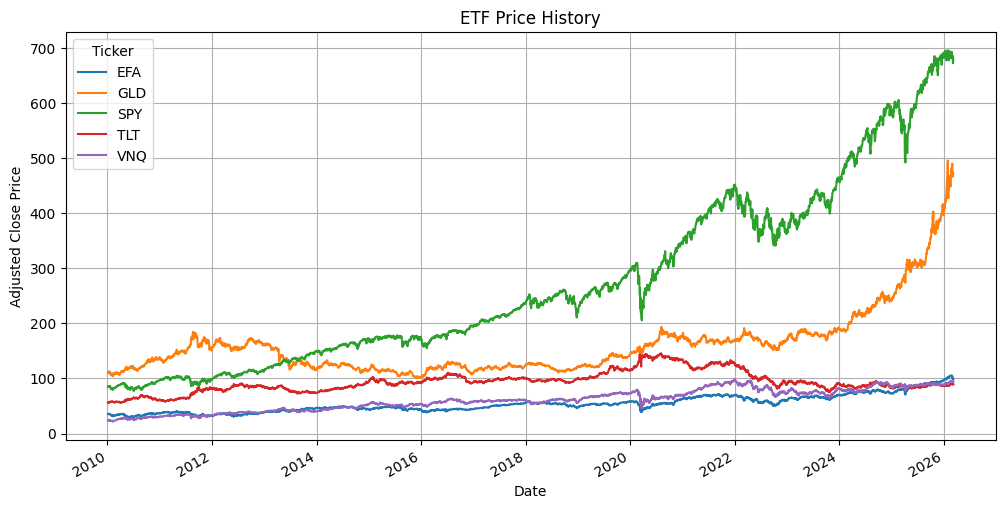

In [7]:
prices.plot()

plt.title("ETF Price History")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.show()

## Return Calculation

Portfolio optimization models are based on **asset returns**, rather than raw prices.

If $P_t$ represents the price of an asset at time $t$, the **log return** is defined as

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns are commonly used in financial modeling because:

- they are approximately normally distributed for many assets
- they are **additive over time** (multi-period returns can be obtained by summing log returns across periods)
- they behave well in statistical models

In the following section, we compute daily log returns for each asset.

In [8]:
returns = np.log(prices / prices.shift(1))

returns = returns.dropna()

returns.head()

Ticker,EFA,GLD,SPY,TLT,VNQ
Date,,,,,
2010-01-05,0.0009,-0.0009,0.0026,0.0064,-0.0011
2010-01-06,0.0042,0.0164,0.0007,-0.0135,-0.0018
2010-01-07,-0.0039,-0.0062,0.0042,0.0017,0.0107
2010-01-08,0.0079,0.0050,0.0033,-0.0004,-0.0074
2010-01-11,0.0082,0.0132,0.0014,-0.0055,0.0058


## Daily Returns Over Time

The following plot shows daily log returns for each asset.

Returns fluctuate around zero and exhibit periods of higher and lower volatility, which are important features in financial time series.

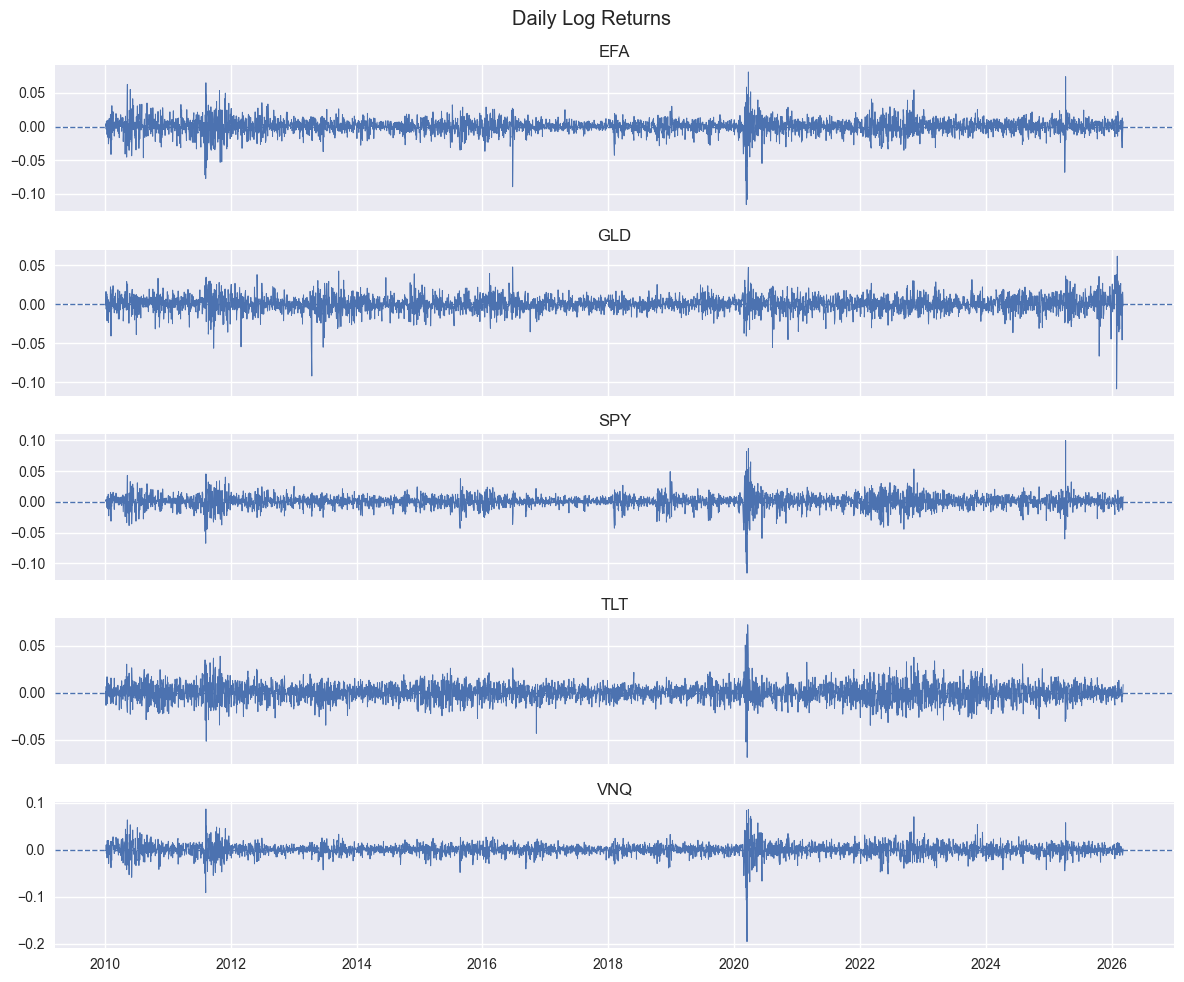

In [27]:
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(12, 10), sharex=True)

for i, col in enumerate(returns.columns):
    axes[i].plot(returns.index, returns[col], linewidth=0.7)
    axes[i].set_title(col)
    axes[i].axhline(0, linestyle="--", linewidth=1)

plt.suptitle("Daily Log Returns")
plt.tight_layout()
plt.show()

## Distribution of Returns

Examining return distributions provides insight into volatility and the shape of asset return behavior.

Financial returns are often:

- centered near zero
- heavy-tailed relative to a normal distribution
- occasionally exhibit large shocks.

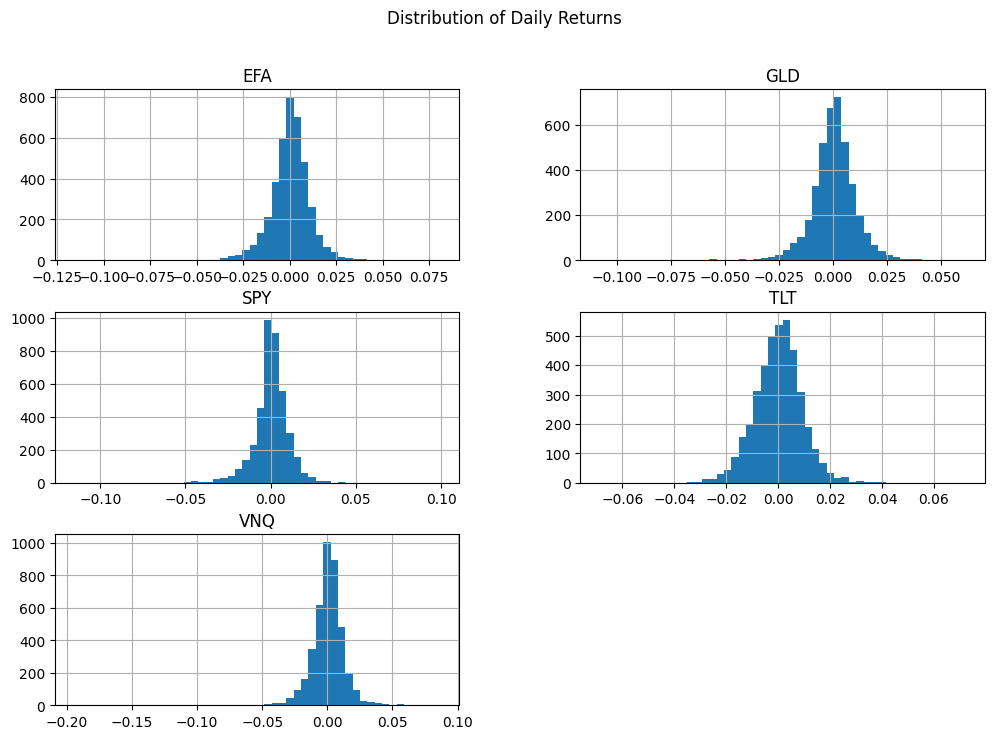

In [15]:
returns.hist(bins=50, layout=(3,2), figsize=(12,8))

plt.suptitle("Distribution of Daily Returns")

plt.show()

## Descriptive Statistics

We compute basic summary statistics for each asset, including:

- mean return
- standard deviation
- minimum and maximum values

These statistics provide an initial view of the risk and return characteristics of each asset.

In [11]:
returns.describe()

Ticker,EFA,GLD,SPY,TLT,VNQ
count,4068.0000,4068.0000,4068.0000,4068.0000,4068.0000
mean,0.0003,0.0004,0.0005,0.0001,0.0003
std,0.0116,0.0103,0.0108,0.0095,0.0129
min,-0.1164,-0.1084,-0.1159,-0.0690,-0.1951
25%,-0.0051,-0.0048,-0.0037,-0.0056,-0.0056
50%,0.0007,0.0005,0.0007,0.0006,0.0008
75%,0.0063,0.0057,0.0058,0.0057,0.0070
max,0.0813,0.0616,0.0999,0.0725,0.0871


## Annualized Return and Volatility

Daily returns can be scaled to annual values using the approximate number of trading days in a year (252).

Annualized mean return:

$$
\mu_{annual} = 252 \times \mu_{daily}
$$

Annualized volatility:

$$
\sigma_{annual} = \sqrt{252} \times \sigma_{daily}
$$

In [12]:
mean_returns = returns.mean() * 252
volatility = returns.std() * np.sqrt(252)

summary = pd.DataFrame({
    "Annual Return": mean_returns,
    "Annual Volatility": volatility
})

summary

,Annual Return,Annual Volatility
Ticker,,
EFA,0.0642,0.1842
GLD,0.0904,0.1640
SPY,0.1286,0.1719
TLT,0.0282,0.1504
VNQ,0.0849,0.2055


## Risk–Return Comparison

A common way to visualize assets is by plotting expected return against volatility.

Assets with higher expected return often come with higher risk.

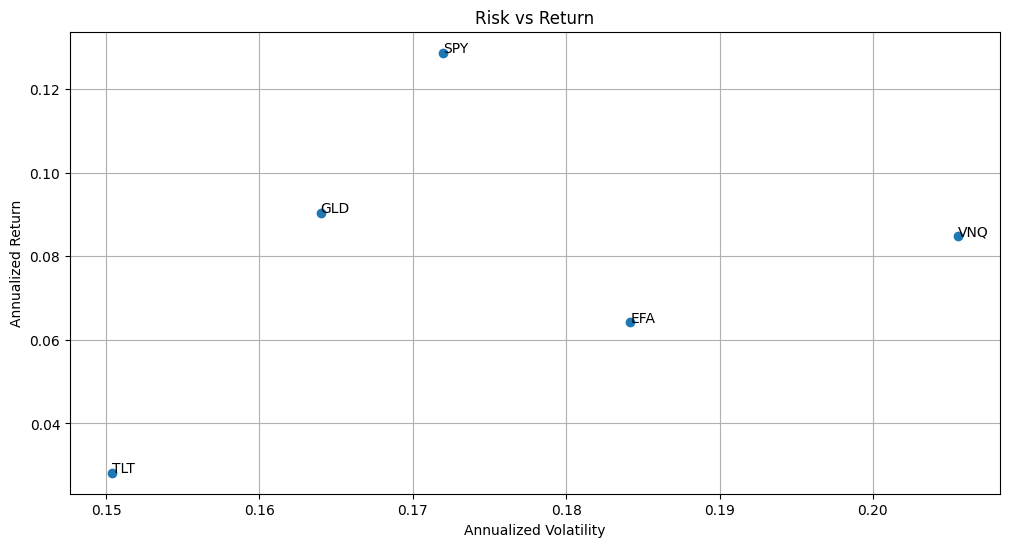

In [13]:
plt.scatter(volatility, mean_returns)

for asset in volatility.index:
    plt.text(volatility[asset], mean_returns[asset], asset)

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Risk vs Return")

plt.show()

This plot provides a useful descriptive comparison, although estimated average returns over a finite sample can be noisy and sensitive to the chosen time period.

### Observations

Several features of financial return series are visible:

- Returns fluctuate around zero, consistent with the idea that asset prices follow approximately random movements over short horizons.
- Periods of **volatility clustering** are visible, where large fluctuations occur in groups rather than being evenly spread over time.
- A large spike in volatility appears around **early 2020**, corresponding to the COVID-19 market crash.
- Equity-related assets such as **SPY, EFA, and VNQ** appear to exhibit larger fluctuations than bonds (**TLT**).

These patterns will become important later when modeling market regimes and estimating covariance structures.

## Correlation Between Assets

Portfolio diversification depends on the correlation structure between assets.

If assets are highly correlated, they tend to move together, limiting diversification benefits.  
Assets with lower or negative correlations can reduce overall portfolio risk when combined.

The following heatmap shows the pairwise correlations between asset returns.

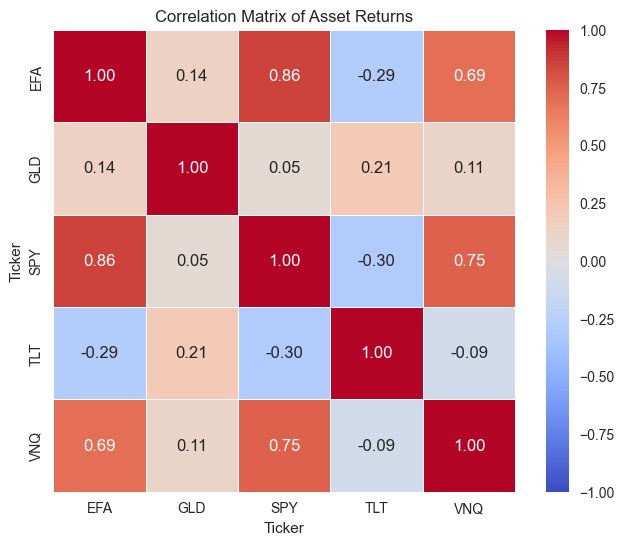

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Asset Returns")
plt.grid(False)
plt.show()

### Interpretation

Several notable relationships appear in the correlation matrix:

- **SPY and EFA** show a strong positive correlation, reflecting the tendency of global equity markets to move together.
- **VNQ** (real estate) is also highly correlated with equities, since REITs behave similarly to stocks.
- **TLT** (long-term Treasury bonds) exhibits negative correlation with equities, highlighting its potential role as a hedge during market downturns.
- **GLD** (gold) shows relatively weak correlations with other assets, which may provide diversification benefits.

These relationships illustrate why combining multiple asset classes can reduce overall portfolio risk.

In [30]:
prices.to_csv("../data/processed/asset_prices.csv")
returns.to_csv("../data/processed/asset_returns.csv")

---

## Key Takeaways

This notebook introduced the financial dataset that will be used throughout the project and explored several basic properties of the asset returns.

Key observations include:

- Daily returns for all assets fluctuate around zero, consistent with the behavior expected from short-horizon financial returns.
- Periods of **volatility clustering** are visible, where large fluctuations tend to occur in groups rather than appearing randomly through time. A notable example occurs during the **2020 COVID-19 market shock**.
- Equity-related assets (**SPY, EFA, VNQ**) exhibit larger fluctuations compared with **TLT** (Treasury bonds), reflecting their higher risk.
- The correlation matrix reveals meaningful relationships between assets:
  - **SPY and EFA** are highly correlated, reflecting global equity market co-movement.
  - **VNQ** (real estate) behaves similarly to equities.
  - **TLT** shows negative correlation with equities, suggesting potential hedging benefits.
  - **GLD** (gold) exhibits relatively weak correlations with other assets.

These observations highlight the importance of **diversification** when constructing portfolios. Assets with lower or negative correlations can reduce overall portfolio risk when combined.

In the next stage of the project, we will estimate **covariance matrices of asset returns**, which form the core input for **mean-variance portfolio optimization**.